# Week 9 V3 Fixed: End-to-End Learned Query Evaluation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aniJani/reposynth/blob/Research/research/Week9_V3_Fixed_Evaluation.ipynb)

**Requirements:** Google Colab with GPU (A100 recommended for CodeLlama)

## What Was Wrong with Original V3?

1. **Bad training data**: Generated from keyword extraction, not real CCE patterns
2. **Model collapse**: Learned model kept predicting `__version__.py` for everything
3. **Path-only embeddings**: Files embedded using just path names, not content

## This Fixed Version:

1. **Loads pre-trained Week11 model** (trained on quality data with 64% improvement over heuristic)
2. **Uses content-aware file embeddings** (extracts docstrings, signatures)
3. **Proper end-to-end CCE integration** with CodeLlama
4. **Fair comparison** against heuristic baseline

## 1. Setup & Installation

In [1]:
# Check GPU
!nvidia-smi

Thu Jan 29 01:08:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# Install dependencies
!pip install -q torch transformers accelerate bitsandbytes sentence-transformers scipy scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 40.1 MB/s eta 0:00:00


In [3]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import time
import random
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Any, Optional
from sentence_transformers import SentenceTransformer
from scipy.stats import entropy as scipy_entropy
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Colab check
try:
    from google.colab import files
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Running in Google Colab
Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.5 GB


## 2. Clone Codebase (httpx)

In [4]:
# Clone httpx repository
REPO_URL = 'https://github.com/encode/httpx.git'
REPO_DIR = '/content/httpx'

if not os.path.exists(REPO_DIR):
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
    print("Cloned httpx repository")
else:
    print("httpx already exists")

!ls {REPO_DIR}

Cloning into '/content/httpx'...
remote: Enumerating objects: 140, done.
remote: Counting objects: 100% (140/140), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 140 (delta 2), reused 50 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (140/140), 2.21 MiB | 16.78 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Cloned httpx repository
CHANGELOG.md  httpx	  mkdocs.yml	  README.md	    scripts
docs	      LICENSE.md  pyproject.toml  requirements.txt  tests


In [7]:
def load_codebase(repo_dir: str, src_folder: str = 'httpx') -> Dict[str, str]:
    """Load all Python files from the codebase."""
    documents = {}
    src_path = os.path.join(repo_dir, src_folder)

    for root, dirs, files_list in os.walk(src_path):
        # Skip test directories
        dirs[:] = [d for d in dirs if 'test' not in d.lower()]

        for file in files_list:
            if file.endswith('.py') and not file.startswith('test_'):
                filepath = os.path.join(root, file)
                rel_path = os.path.relpath(filepath, repo_dir)
                try:
                    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
                        content = f.read()
                    if len(content) > 100:  # Skip tiny files
                        documents[rel_path] = content
                except Exception as e:
                    print(f"Error reading {rel_path}: {e}")

    return documents

CODEBASE = load_codebase(REPO_DIR)
FILE_LIST = list(CODEBASE.keys())
FILE_TO_IDX = {f: i for i, f in enumerate(FILE_LIST)}

print(f"Loaded {len(CODEBASE)} files")
for f in FILE_LIST:
    print(f"  {f}")

Loaded 23 files
  httpx/_client.py
  httpx/_config.py
  httpx/_decoders.py
  httpx/__init__.py
  httpx/_utils.py
  httpx/_types.py
  httpx/__version__.py
  httpx/_auth.py
  httpx/_urlparse.py
  httpx/_api.py
  httpx/_urls.py
  httpx/_main.py
  httpx/_status_codes.py
  httpx/_exceptions.py
  httpx/_multipart.py
  httpx/_models.py
  httpx/_content.py
  httpx/_transports/__init__.py
  httpx/_transports/wsgi.py
  httpx/_transports/asgi.py
  httpx/_transports/base.py
  httpx/_transports/default.py
  httpx/_transports/mock.py


## 3. Define Benchmark Examples

In [8]:
@dataclass
class BenchmarkExample:
    """Benchmark example for evaluation."""
    id: str
    query: str
    ground_truth_files: List[str]
    ground_truth_answer: str
    keywords: List[str] = field(default_factory=list)

# Define benchmark for httpx (same as original V3)
BENCHMARK = [
    BenchmarkExample(
        id="httpx_001",
        query="How do I make a simple GET request with httpx?",
        ground_truth_files=["httpx/_api.py", "httpx/_client.py"],
        ground_truth_answer="Use httpx.get(url) for synchronous requests or async with httpx.AsyncClient().",
        keywords=["get", "request", "client"]
    ),
    BenchmarkExample(
        id="httpx_002",
        query="How do I send POST data with httpx?",
        ground_truth_files=["httpx/_api.py", "httpx/_client.py"],
        ground_truth_answer="Use httpx.post(url, data=dict) or json=dict for JSON data.",
        keywords=["post", "data", "json"]
    ),
    BenchmarkExample(
        id="httpx_003",
        query="How do I use httpx with async/await?",
        ground_truth_files=["httpx/_client.py"],
        ground_truth_answer="Use async with httpx.AsyncClient() as client: response = await client.get(url).",
        keywords=["async", "await", "AsyncClient"]
    ),
    BenchmarkExample(
        id="httpx_004",
        query="How do I set custom headers in httpx?",
        ground_truth_files=["httpx/_client.py", "httpx/_models.py"],
        ground_truth_answer="Pass headers={'key': 'value'} to request methods or client constructor.",
        keywords=["headers", "Headers"]
    ),
    BenchmarkExample(
        id="httpx_005",
        query="How do I handle timeouts in httpx?",
        ground_truth_files=["httpx/_config.py", "httpx/_client.py"],
        ground_truth_answer="Use timeout parameter: httpx.get(url, timeout=10.0) or Timeout object.",
        keywords=["timeout", "Timeout"]
    ),
    BenchmarkExample(
        id="httpx_006",
        query="How does httpx handle cookies?",
        ground_truth_files=["httpx/_client.py", "httpx/_models.py"],
        ground_truth_answer="Cookies persist in Client sessions. Use cookies parameter or client.cookies.",
        keywords=["cookies", "Cookies"]
    ),
    BenchmarkExample(
        id="httpx_007",
        query="How do I handle authentication in httpx?",
        ground_truth_files=["httpx/_auth.py", "httpx/_client.py"],
        ground_truth_answer="Use auth parameter with tuple (user, pass) or Auth class for custom auth.",
        keywords=["auth", "authentication", "BasicAuth"]
    ),
    BenchmarkExample(
        id="httpx_008",
        query="How does httpx handle redirects?",
        ground_truth_files=["httpx/_client.py"],
        ground_truth_answer="Redirects are followed by default. Use follow_redirects=False to disable.",
        keywords=["redirect", "follow_redirects"]
    ),
    BenchmarkExample(
        id="httpx_009",
        query="How do I upload files with httpx?",
        ground_truth_files=["httpx/_content.py", "httpx/_client.py"],
        ground_truth_answer="Use files parameter: httpx.post(url, files={'file': open('file.txt', 'rb')}).",
        keywords=["files", "upload", "multipart"]
    ),
    BenchmarkExample(
        id="httpx_010",
        query="How does httpx handle HTTP/2?",
        ground_truth_files=["httpx/_transports/default.py", "httpx/_client.py"],
        ground_truth_answer="Enable HTTP/2 with http2=True in Client constructor.",
        keywords=["http2", "HTTP/2"]
    ),
]

# Filter to only include files that exist in our codebase
for ex in BENCHMARK:
    ex.ground_truth_files = [f for f in ex.ground_truth_files if f in FILE_TO_IDX]

print(f"Benchmark: {len(BENCHMARK)} examples")
for ex in BENCHMARK[:3]:
    print(f"  {ex.id}: {ex.ground_truth_files}")

Benchmark: 10 examples
  httpx_001: ['httpx/_api.py', 'httpx/_client.py']
  httpx_002: ['httpx/_api.py', 'httpx/_client.py']
  httpx_003: ['httpx/_client.py']


## 4. Define Learned Query Module (Week11 Architecture)

In [9]:
# ============================================================================
# CONFUSED TOKEN ENCODER
# ============================================================================

class ConfusedTokenEncoder(nn.Module):
    def __init__(self, embed_dim=384, model_name='all-MiniLM-L6-v2', dropout=0.1, max_tokens=20):
        super().__init__()
        self.embed_dim = embed_dim
        self.max_tokens = max_tokens
        self._encoder = SentenceTransformer(model_name)
        test_emb = self._encoder.encode(["test"])
        actual_dim = test_emb.shape[1]
        self._projection = nn.Linear(actual_dim, embed_dim) if actual_dim != embed_dim else None
        self.prob_transform = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
        self.dropout = nn.Dropout(dropout)
        self.output_norm = nn.LayerNorm(embed_dim)

    def forward(self, tokens, probabilities=None, return_weights=False):
        if not tokens:
            empty = torch.zeros(1, self.embed_dim, device=device)
            return (empty, torch.ones(1, device=device)) if return_weights else empty
        tokens = tokens[:self.max_tokens]
        with torch.no_grad():
            raw_emb = self._encoder.encode(tokens, convert_to_tensor=True, show_progress_bar=False)
        embeddings = raw_emb.clone().to(device)  # Clone to escape inference mode
        if self._projection:
            embeddings = self._projection(embeddings)
        embeddings = self.dropout(embeddings)
        if probabilities:
            probs = probabilities[:len(tokens)]
            prob_tensor = torch.tensor(probs, dtype=torch.float32, device=device).unsqueeze(-1)
            weights = self.prob_transform(prob_tensor).squeeze(-1)
            embeddings = embeddings * weights.unsqueeze(-1)
        else:
            weights = torch.ones(len(tokens), device=device)
        embeddings = self.output_norm(embeddings)
        return (embeddings, weights) if return_weights else embeddings

print("ConfusedTokenEncoder defined")

ConfusedTokenEncoder defined


In [10]:
# ============================================================================
# CONTEXT ENCODER
# ============================================================================

class ContextEncoder(nn.Module):
    def __init__(self, embed_dim=384, model_name='all-MiniLM-L6-v2', dropout=0.1, chunk_size=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.chunk_size = chunk_size
        self._encoder = SentenceTransformer(model_name)
        test_emb = self._encoder.encode(["test"])
        actual_dim = test_emb.shape[1]
        self._projection = nn.Linear(actual_dim, embed_dim) if actual_dim != embed_dim else None
        self.dropout = nn.Dropout(dropout)
        self.type_embeddings = nn.Embedding(2, embed_dim)
        self.output_norm = nn.LayerNorm(embed_dim)

    def forward(self, query, context, return_separate=False):
        texts, types = [], []
        if query:
            texts.append(query)
            types.append(0)
        for i in range(0, len(context), self.chunk_size):
            chunk = context[i:i+self.chunk_size].strip()
            if chunk:
                texts.append(chunk)
                types.append(1)
        if not texts:
            texts, types = [""], [1]
        with torch.no_grad():
            raw_emb = self._encoder.encode(texts, convert_to_tensor=True, show_progress_bar=False)
        embeddings = raw_emb.clone().to(device)  # Clone to escape inference mode
        if self._projection:
            embeddings = self._projection(embeddings)
        type_tensor = torch.tensor(types, dtype=torch.long, device=device)
        embeddings = embeddings + self.type_embeddings(type_tensor)
        embeddings = self.dropout(embeddings)
        embeddings = self.output_norm(embeddings)
        if return_separate and query:
            return embeddings[0:1], embeddings[1:] if len(embeddings) > 1 else embeddings
        return embeddings

print("ContextEncoder defined")

ContextEncoder defined


In [11]:
# ============================================================================
# LEARNED QUERY POOLER (with Gnosis-inspired improvements)
# ============================================================================

class LearnedQueryPooler(nn.Module):
    """Cross-attention based query pooler inspired by Gnosis PMA."""

    def __init__(self, embed_dim=384, num_query_vectors=4, num_heads=4, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim

        # Learnable query vectors (like Gnosis PMA seeds)
        self.query_vectors = nn.Parameter(
            torch.randn(num_query_vectors, embed_dim) * 0.02
        )

        # Cross-attention for tokens and context
        self.token_cross_attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.context_cross_attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )

        # Fusion layer
        self.fusion = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # Output projection
        self.output_projection = nn.Linear(embed_dim, embed_dim)

        # Layer norms
        self.token_norm = nn.LayerNorm(embed_dim)
        self.context_norm = nn.LayerNorm(embed_dim)
        self.output_norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, token_embs, context_embs, return_attention_weights=False):
        if token_embs.dim() == 2:
            token_embs = token_embs.unsqueeze(0)
        if context_embs.dim() == 2:
            context_embs = context_embs.unsqueeze(0)

        batch_size = token_embs.shape[0]
        queries = self.query_vectors.unsqueeze(0).expand(batch_size, -1, -1)

        # Cross-attend to tokens
        token_attended, token_attn = self.token_cross_attn(queries, token_embs, token_embs)
        token_attended = self.token_norm(token_attended)

        # Cross-attend to context
        context_attended, context_attn = self.context_cross_attn(queries, context_embs, context_embs)
        context_attended = self.context_norm(context_attended)

        # Fuse and pool
        fused = self.fusion(torch.cat([token_attended, context_attended], dim=-1))
        pooled = fused.mean(dim=1)
        output = self.output_norm(self.dropout(self.output_projection(pooled)))

        if batch_size == 1:
            output = output.squeeze(0)

        attn = {'token_attention': token_attn, 'context_attention': context_attn} if return_attention_weights else None
        return output, attn

print("LearnedQueryPooler defined")

LearnedQueryPooler defined


In [12]:
# ============================================================================
# FILE SCORER & CONTENT-AWARE CACHE (FIXED: Uses file content, not just paths)
# ============================================================================

class LearnedFileScorer(nn.Module):
    def __init__(self, embed_dim=384, scoring_method="bilinear", dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.scoring_method = scoring_method
        if scoring_method == "bilinear":
            self.bilinear = nn.Bilinear(embed_dim, embed_dim, 1, bias=True)
        self.query_projection = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query_emb, file_embs, return_probabilities=False):
        if query_emb.dim() == 1:
            query_emb = query_emb.unsqueeze(0)
        if file_embs.dim() == 2:
            file_embs = file_embs.unsqueeze(0)
        batch_size, num_files = query_emb.shape[0], file_embs.shape[1]
        query_emb = self.dropout(self.query_projection(query_emb))
        if self.scoring_method == "bilinear":
            query_exp = query_emb.unsqueeze(1).expand(-1, num_files, -1).reshape(-1, self.embed_dim)
            file_flat = file_embs.reshape(-1, self.embed_dim)
            scores = self.bilinear(query_exp, file_flat).reshape(batch_size, num_files)
        else:  # cosine
            query_norm = F.normalize(query_emb, p=2, dim=-1)
            file_norm = F.normalize(file_embs, p=2, dim=-1)
            scores = torch.bmm(query_norm.unsqueeze(1), file_norm.transpose(1, 2)).squeeze(1)
        scores = scores.squeeze(0) if batch_size == 1 else scores
        if return_probabilities:
            return scores, F.softmax(scores, dim=-1)
        return scores


class ContentAwareFileCache:
    """FIXED: Embeds files using content, not just path names."""

    def __init__(self, model_name='all-MiniLM-L6-v2'):
        self._encoder = SentenceTransformer(model_name)
        self._file_paths = []

    def _extract_file_summary(self, path: str, content: str) -> str:
        """Extract meaningful summary from file content."""
        parts = []

        # 1. Path parts
        path_parts = re.split(r'[/\\._]', path.lower())
        parts.append(' '.join(p for p in path_parts if len(p) >= 2))

        # 2. Module docstring
        docstring_match = re.search(r'^"""(.+?)"""', content, re.DOTALL)
        if docstring_match:
            docstring = docstring_match.group(1).strip()[:200]
            parts.append(docstring)

        # 3. Class names with their docstrings
        for match in re.finditer(r'class\s+(\w+)[^:]*:\s*(?:"""(.+?)""")?', content, re.DOTALL):
            class_name = match.group(1)
            class_doc = match.group(2)[:50] if match.group(2) else ''
            parts.append(f"class {class_name} {class_doc}")

        # 4. Function names
        for match in re.finditer(r'def\s+(\w+)\s*\(', content):
            if not match.group(1).startswith('_'):
                parts.append(match.group(1))

        # 5. First 300 chars of content
        parts.append(content[:300])

        return ' '.join(parts)[:1000]

    def build_cache(self, file_paths: List[str], file_contents: Dict[str, str]) -> torch.Tensor:
        """Build content-aware file embeddings."""
        self._file_paths = file_paths

        summaries = []
        for path in file_paths:
            content = file_contents.get(path, '')
            summary = self._extract_file_summary(path, content)
            summaries.append(summary)

        embeddings = self._encoder.encode(summaries, show_progress_bar=True)
        return torch.tensor(embeddings, dtype=torch.float32, device=device)

print("LearnedFileScorer and ContentAwareFileCache defined")

LearnedFileScorer and ContentAwareFileCache defined


In [13]:
# ============================================================================
# LEARNED QUERY MODULE (MAIN)
# ============================================================================

@dataclass
class LearnedQueryResult:
    query_embedding: torch.Tensor
    matched_files: List[str]
    file_scores: Dict[str, float]
    confidence: float
    token_attention: Optional[torch.Tensor] = None
    context_attention: Optional[torch.Tensor] = None


class LearnedQueryModule(nn.Module):
    def __init__(self, embed_dim=384, num_query_vectors=4, num_heads=4, dropout=0.1,
                 model_name='all-MiniLM-L6-v2', scoring_method="bilinear",
                 score_threshold=0.1, top_k=3):
        super().__init__()
        self.embed_dim = embed_dim
        self.score_threshold = score_threshold
        self.top_k = top_k

        self.token_encoder = ConfusedTokenEncoder(embed_dim=embed_dim, model_name=model_name, dropout=dropout)
        self.context_encoder = ContextEncoder(embed_dim=embed_dim, model_name=model_name, dropout=dropout)
        self.pooler = LearnedQueryPooler(embed_dim=embed_dim, num_query_vectors=num_query_vectors, num_heads=num_heads, dropout=dropout)
        self.scorer = LearnedFileScorer(embed_dim=embed_dim, scoring_method=scoring_method, dropout=dropout)
        self.file_cache = ContentAwareFileCache(model_name=model_name)

        self._file_paths = []
        self._file_embeddings = None

    def set_available_files(self, file_paths: List[str], file_contents: Dict[str, str]):
        """Set files with content-aware embeddings."""
        self._file_paths = file_paths
        self._file_embeddings = self.file_cache.build_cache(file_paths, file_contents)

    def forward(self, confused_tokens, confused_probs=None, original_query="", generated_context="", return_attention=False):
        if not confused_tokens:
            return LearnedQueryResult(torch.zeros(self.embed_dim, device=device), [], {}, 0.0)

        token_embs, _ = self.token_encoder(confused_tokens, confused_probs, return_weights=True)
        context_embs = self.context_encoder(original_query, generated_context)
        query_emb, attn = self.pooler(token_embs, context_embs, return_attention_weights=True)

        file_scores = {}
        if self._file_embeddings is not None:
            _, probs = self.scorer(query_emb, self._file_embeddings, return_probabilities=True)
            scores_np = probs.detach().cpu().numpy()
            for i, path in enumerate(self._file_paths):
                file_scores[path] = float(scores_np[i])

        sorted_files = sorted(file_scores.items(), key=lambda x: -x[1])
        matched_files = [f for f, s in sorted_files[:self.top_k] if s >= self.score_threshold]

        confidence = 0.5
        if attn and attn.get('token_attention') is not None:
            with torch.no_grad():
                a = attn['token_attention'].mean(dim=(0,1)).clamp(min=1e-8)
                entropy = -(a * torch.log(a)).sum()
                max_ent = np.log(len(a)) if len(a) > 1 else 1.0
                confidence = float(max(0.0, min(1.0, 1.0 - entropy.item() / max_ent))) if max_ent > 0 else 0.5

        result = LearnedQueryResult(query_emb, matched_files, file_scores, confidence)
        if return_attention and attn:
            result.token_attention = attn.get('token_attention')
            result.context_attention = attn.get('context_attention')
        return result

print("LearnedQueryModule defined")

LearnedQueryModule defined


## 5. Define Heuristic Baseline

In [14]:
class HeuristicMatcher:
    """Keyword-based file matching (baseline)."""

    def __init__(self, file_paths: List[str], file_contents: Dict[str, str]):
        self.file_paths = file_paths
        self.file_kw = {}

        for path in file_paths:
            # Path keywords
            parts = re.split(r'[/\\._]', path.lower())
            keywords = set(p for p in parts if len(p) >= 2)

            # Content keywords (function/class names)
            content = file_contents.get(path, '')
            for match in re.finditer(r'(?:def|class)\s+(\w+)', content):
                keywords.add(match.group(1).lower())

            self.file_kw[path] = keywords

    def match(self, tokens: List[str], query: str = "", top_k: int = 3) -> List[str]:
        keywords = set(t.lower() for t in tokens)
        keywords.update(w.lower() for w in re.findall(r'\w+', query) if len(w) >= 2)

        scores = {}
        for path, kw in self.file_kw.items():
            scores[path] = len(keywords & kw)

        sorted_files = sorted(scores.items(), key=lambda x: -x[1])
        return [f for f, _ in sorted_files[:top_k]]

print("HeuristicMatcher defined")

HeuristicMatcher defined


## 6. Initialize Models

In [15]:
# Initialize learned module
learned_model = LearnedQueryModule(
    embed_dim=384,
    num_query_vectors=4,
    num_heads=4,
    scoring_method="bilinear",
    top_k=3,
).to(device)

# Set files with CONTENT-AWARE embeddings (the fix!)
learned_model.set_available_files(FILE_LIST, CODEBASE)

# Initialize heuristic baseline
heuristic_matcher = HeuristicMatcher(FILE_LIST, CODEBASE)

print(f"Models initialized with {len(FILE_LIST)} files")
print(f"Learned model parameters: {sum(p.numel() for p in learned_model.parameters() if p.requires_grad):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Models initialized with 23 files
Learned model parameters: 47,353,778


In [16]:
# ============================================================================
# OPTIONAL: Upload pre-trained Week11 weights
# ============================================================================

USE_PRETRAINED = False

if IN_COLAB:
    print("Upload learned_query_pooler_week11.pt (or skip for zero-shot):")
    try:
        uploaded = files.upload()
        if uploaded:
            filename = list(uploaded.keys())[0]
            state_dict = torch.load(filename, map_location=device)

            # Load compatible weights (ignore file cache differences)
            model_dict = learned_model.state_dict()
            compatible = {k: v for k, v in state_dict.items() if k in model_dict and v.shape == model_dict[k].shape}
            model_dict.update(compatible)
            learned_model.load_state_dict(model_dict)

            USE_PRETRAINED = True
            print(f"Loaded {len(compatible)}/{len(state_dict)} weights from Week11 model")
    except Exception as e:
        print(f"No weights uploaded, using zero-shot: {e}")
else:
    print("Running locally. Set USE_PRETRAINED=True and load weights manually if available.")

Upload learned_query_pooler_week11.pt (or skip for zero-shot):


Saving learned_query_pooler.pt to learned_query_pooler.pt
Loaded 238/238 weights from Week11 model


## 7. Load CodeLlama for End-to-End Evaluation

In [17]:
# Load CodeLlama with 4-bit quantization
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"

print(f"Loading {MODEL_NAME}...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
llm = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Model loaded!")

Loading codellama/CodeLlama-7b-Instruct-hf...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded!


## 8. Define CCE Spike Detection

In [18]:
class CCESpikeDetector:
    """Detect entropy spikes during generation."""

    def __init__(self, tokenizer, threshold: float = 3.0, cooldown: int = 15):
        self.tokenizer = tokenizer
        self.threshold = threshold
        self.cooldown = cooldown
        self.last_spike = -cooldown

        # Build code token indices
        self.code_indices = []
        vocab_size = min(tokenizer.vocab_size, 32000)
        for idx in range(vocab_size):
            try:
                token = tokenizer.decode([idx])
                if re.search(r'[_A-Z]{2,}|\(|\)|\{|\}|def|class|import|return', token):
                    self.code_indices.append(idx)
            except:
                pass
        self.code_indices = torch.tensor(self.code_indices, device=device)

    def compute_cce(self, logits: torch.Tensor) -> float:
        """Compute code-conditional entropy."""
        probs = F.softmax(logits, dim=-1)
        if len(self.code_indices) > 0:
            code_probs = probs[self.code_indices].cpu().numpy()
            total = code_probs.sum()
            if total > 1e-10:
                code_probs = code_probs / total
                return float(scipy_entropy(code_probs + 1e-10, base=2))
        return 0.0

    def check_spike(self, logits: torch.Tensor, position: int) -> Tuple[bool, float]:
        """Check if current position is a spike."""
        cce = self.compute_cce(logits)
        is_spike = cce > self.threshold and (position - self.last_spike) >= self.cooldown
        if is_spike:
            self.last_spike = position
        return is_spike, cce

    def get_confused_tokens(self, logits: torch.Tensor, top_k: int = 5) -> Tuple[List[str], List[float]]:
        """Get top confused tokens."""
        probs = F.softmax(logits, dim=-1)
        top_probs, top_indices = torch.topk(probs, top_k)

        tokens = []
        token_probs = []
        for idx, prob in zip(top_indices.tolist(), top_probs.tolist()):
            token = self.tokenizer.decode([idx]).strip()
            if len(token) >= 2:
                tokens.append(token)
                token_probs.append(prob)

        return tokens, token_probs

    def reset(self):
        self.last_spike = -self.cooldown

spike_detector = CCESpikeDetector(tokenizer, threshold=3.0, cooldown=15)
print(f"CCESpikeDetector initialized with {len(spike_detector.code_indices)} code tokens")

CCESpikeDetector initialized with 1634 code tokens


## 9. Define Generation Functions

In [19]:
@dataclass
class GenerationResult:
    """Result of generation."""
    answer: str
    retrieved_files: List[str]
    num_spikes: int
    tokens_used: int
    generation_time: float


def generate_with_cce(
    query: str,
    matcher,
    use_learned: bool,
    max_tokens: int = 100,
    max_retrievals: int = 3,
) -> GenerationResult:
    """Generate with CCE-triggered retrieval."""
    start_time = time.time()
    spike_detector.reset()

    prompt = f"Question: {query}\nAnswer:"
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

    retrieved_files = []
    num_spikes = 0
    generated_text = ""

    for step in range(max_tokens):
        with torch.no_grad():
            outputs = llm(input_ids)
            logits = outputs.logits[:, -1, :]

        # Check for spike
        is_spike, cce = spike_detector.check_spike(logits[0], step)

        if is_spike and num_spikes < max_retrievals:
            # Get confused tokens
            tokens, probs = spike_detector.get_confused_tokens(logits[0])

            # Get files based on method
            if use_learned:
                learned_model.eval()
                with torch.no_grad():
                    result = learned_model(
                        confused_tokens=tokens,
                        confused_probs=probs,
                        original_query=query,
                        generated_context=generated_text,
                    )
                files = result.matched_files[:2]
            else:
                files = matcher.match(tokens, query, top_k=2)

            retrieved_files.extend(files)
            num_spikes += 1

            # Inject context
            if files:
                context_text = ""
                for f in files[:1]:  # Use first file
                    if f in CODEBASE:
                        context_text = f"\n[From {f}]:\n{CODEBASE[f][:300]}\n"
                        break

                if context_text:
                    context_ids = tokenizer.encode(context_text, return_tensors='pt').to(device)
                    input_ids = torch.cat([input_ids, context_ids], dim=-1)

        # Sample next token
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        input_ids = torch.cat([input_ids, next_token], dim=-1)
        generated_text += tokenizer.decode(next_token[0])

        # Stop on EOS
        if next_token.item() == tokenizer.eos_token_id:
            break

    # Decode final answer
    full_output = tokenizer.decode(input_ids[0], skip_special_tokens=True)
    answer = full_output.split("Answer:")[-1].strip()[:500]

    return GenerationResult(
        answer=answer,
        retrieved_files=list(set(retrieved_files)),
        num_spikes=num_spikes,
        tokens_used=input_ids.shape[1],
        generation_time=time.time() - start_time
    )


def generate_no_retrieval(query: str, max_tokens: int = 100) -> GenerationResult:
    """Generate without any retrieval (baseline)."""
    start_time = time.time()

    prompt = f"Question: {query}\nAnswer:"
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

    with torch.no_grad():
        outputs = llm.generate(
            input_ids,
            max_new_tokens=max_tokens,
            do_sample=True,
            temperature=0.7,
            pad_token_id=tokenizer.pad_token_id,
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = answer.split("Answer:")[-1].strip()[:500]

    return GenerationResult(
        answer=answer,
        retrieved_files=[],
        num_spikes=0,
        tokens_used=outputs.shape[1],
        generation_time=time.time() - start_time
    )

print("Generation functions defined")

Generation functions defined


## 10. Define Evaluation Metrics

In [20]:
class Evaluator:
    """Evaluate generation quality."""

    def __init__(self):
        self.encoder = SentenceTransformer('all-MiniLM-L6-v2')

    def semantic_similarity(self, text1: str, text2: str) -> float:
        """Compute semantic similarity."""
        if not text1 or not text2:
            return 0.0
        embs = self.encoder.encode([text1, text2])
        sim = np.dot(embs[0], embs[1]) / (np.linalg.norm(embs[0]) * np.linalg.norm(embs[1]) + 1e-8)
        return float(max(0, sim))

    def retrieval_metrics(self, retrieved: List[str], ground_truth: List[str]) -> Dict:
        """Compute retrieval metrics."""
        if not retrieved or not ground_truth:
            return {'precision': 0, 'recall': 0, 'f1': 0}

        retrieved_set = set(retrieved)
        gt_set = set(ground_truth)
        hits = len(retrieved_set & gt_set)

        precision = hits / len(retrieved_set)
        recall = hits / len(gt_set)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        return {'precision': precision, 'recall': recall, 'f1': f1}

    def evaluate(self, result: GenerationResult, example: BenchmarkExample) -> Dict:
        """Full evaluation."""
        correctness = self.semantic_similarity(result.answer, example.ground_truth_answer)
        ret_metrics = self.retrieval_metrics(result.retrieved_files, example.ground_truth_files)

        # Composite score
        composite = 0.4 * correctness + 0.3 * ret_metrics['f1'] + 0.2 * (1 - max(0, 1 - correctness) * 0.5) + 0.1

        return {
            'correctness': correctness,
            'precision': ret_metrics['precision'],
            'recall': ret_metrics['recall'],
            'f1': ret_metrics['f1'],
            'composite': composite,
            'num_spikes': result.num_spikes,
            'tokens': result.tokens_used,
            'time': result.generation_time
        }

evaluator = Evaluator()
print("Evaluator defined")

Evaluator defined


## 11. Run End-to-End Experiment

In [21]:
learned_model.eval()

results = {
    'no_retrieval': [],
    'cce_heuristic': [],
    'cce_learned': []
}

detailed_results = []

print("=" * 70)
print("END-TO-END EXPERIMENT (FIXED VERSION)")
print("=" * 70)
print(f"Benchmark: {len(BENCHMARK)} examples")
print(f"Methods: no_retrieval, cce_heuristic, cce_learned")
print(f"Using content-aware file embeddings: YES")
print(f"Pre-trained weights: {'YES' if USE_PRETRAINED else 'NO (zero-shot)'}")
print()

for i, example in enumerate(BENCHMARK):
    print(f"\n[{i+1}/{len(BENCHMARK)}] {example.query[:50]}...")
    print(f"  Ground truth: {example.ground_truth_files}")

    detail = {'id': example.id, 'query': example.query, 'ground_truth': example.ground_truth_files}

    # No retrieval baseline
    try:
        nr_result = generate_no_retrieval(example.query)
        nr_eval = evaluator.evaluate(nr_result, example)
        results['no_retrieval'].append(nr_eval)
        print(f"  no_retrieval: correct={nr_eval['correctness']:.2f}")
    except Exception as e:
        print(f"  no_retrieval ERROR: {e}")

    # CCE Heuristic
    try:
        heur_result = generate_with_cce(example.query, heuristic_matcher, use_learned=False)
        heur_eval = evaluator.evaluate(heur_result, example)
        results['cce_heuristic'].append(heur_eval)
        detail['heuristic_files'] = heur_result.retrieved_files
        detail['heuristic_f1'] = heur_eval['f1']
        print(f"  cce_heuristic: correct={heur_eval['correctness']:.2f}, F1={heur_eval['f1']:.2f}, files={heur_result.retrieved_files[:2]}")
    except Exception as e:
        print(f"  cce_heuristic ERROR: {e}")

    # CCE Learned
    try:
        learn_result = generate_with_cce(example.query, learned_model, use_learned=True)
        learn_eval = evaluator.evaluate(learn_result, example)
        results['cce_learned'].append(learn_eval)
        detail['learned_files'] = learn_result.retrieved_files
        detail['learned_f1'] = learn_eval['f1']
        print(f"  cce_learned:   correct={learn_eval['correctness']:.2f}, F1={learn_eval['f1']:.2f}, files={learn_result.retrieved_files[:2]}")
    except Exception as e:
        print(f"  cce_learned ERROR: {e}")

    detailed_results.append(detail)

print("\nExperiment complete!")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


END-TO-END EXPERIMENT (FIXED VERSION)
Benchmark: 10 examples
Methods: no_retrieval, cce_heuristic, cce_learned
Using content-aware file embeddings: YES
Pre-trained weights: YES


[1/10] How do I make a simple GET request with httpx?...
  Ground truth: ['httpx/_api.py', 'httpx/_client.py']
  no_retrieval: correct=0.52
  cce_heuristic: correct=0.23, F1=1.00, files=['httpx/_client.py', 'httpx/_api.py']
  cce_learned:   correct=0.17, F1=0.00, files=[]

[2/10] How do I send POST data with httpx?...
  Ground truth: ['httpx/_api.py', 'httpx/_client.py']
  no_retrieval: correct=0.77
  cce_heuristic: correct=0.33, F1=1.00, files=['httpx/_client.py', 'httpx/_api.py']
  cce_learned:   correct=0.18, F1=0.40, files=['httpx/_api.py', 'httpx/_transports/base.py']

[3/10] How do I use httpx with async/await?...
  Ground truth: ['httpx/_client.py']
  no_retrieval: correct=0.78
  cce_heuristic: correct=0.29, F1=0.50, files=['httpx/_client.py', 'httpx/_config.py']
  cce_learned:   correct=0.33, F1=0.00, 

## 12. Aggregate Results

In [22]:
def aggregate(evals: List[Dict]) -> Dict:
    if not evals:
        return {}
    return {
        'Correctness': np.mean([e['correctness'] for e in evals]),
        'Precision': np.mean([e['precision'] for e in evals]),
        'Recall': np.mean([e['recall'] for e in evals]),
        'F1': np.mean([e['f1'] for e in evals]),
        'Composite': np.mean([e['composite'] for e in evals]),
    }

agg_results = {method: aggregate(evals) for method, evals in results.items()}

print("\n" + "=" * 70)
print("AGGREGATED RESULTS")
print("=" * 70)

df = pd.DataFrame(agg_results).T
print(df.round(3).to_string())


AGGREGATED RESULTS
               Correctness  Precision  Recall    F1  Composite
no_retrieval         0.557      0.000    0.00  0.00      0.478
cce_heuristic        0.272      0.658    0.85  0.72      0.552
cce_learned          0.307      0.150    0.20  0.17      0.404


In [23]:
# Comparison
print("\n" + "=" * 70)
print("CCE LEARNED vs CCE HEURISTIC")
print("=" * 70)

if 'cce_learned' in agg_results and 'cce_heuristic' in agg_results:
    learned = agg_results['cce_learned']
    heuristic = agg_results['cce_heuristic']

    for metric in ['Correctness', 'F1', 'Composite']:
        l_val = learned.get(metric, 0)
        h_val = heuristic.get(metric, 0)
        diff = l_val - h_val
        pct = (diff / h_val * 100) if h_val > 0 else 0
        symbol = "^" if diff > 0 else "v" if diff < 0 else "="
        print(f"{metric:12s}: Learned={l_val:.3f}, Heuristic={h_val:.3f}, {symbol} {diff:+.3f} ({pct:+.1f}%)")

    # Verdict
    l_comp = learned.get('Composite', 0)
    h_comp = heuristic.get('Composite', 0)

    print("\n" + "-" * 70)
    if l_comp > h_comp:
        print(f"VERDICT: LEARNED WINS! (+{(l_comp - h_comp) / h_comp * 100:.1f}% composite)")
    elif l_comp < h_comp:
        print(f"VERDICT: Heuristic wins ({(h_comp - l_comp) / h_comp * 100:.1f}% better)")
    else:
        print("VERDICT: TIE")


CCE LEARNED vs CCE HEURISTIC
Correctness : Learned=0.307, Heuristic=0.272, ^ +0.035 (+12.8%)
F1          : Learned=0.170, Heuristic=0.720, v -0.550 (-76.4%)
Composite   : Learned=0.404, Heuristic=0.552, v -0.148 (-26.7%)

----------------------------------------------------------------------
VERDICT: Heuristic wins (26.7% better)


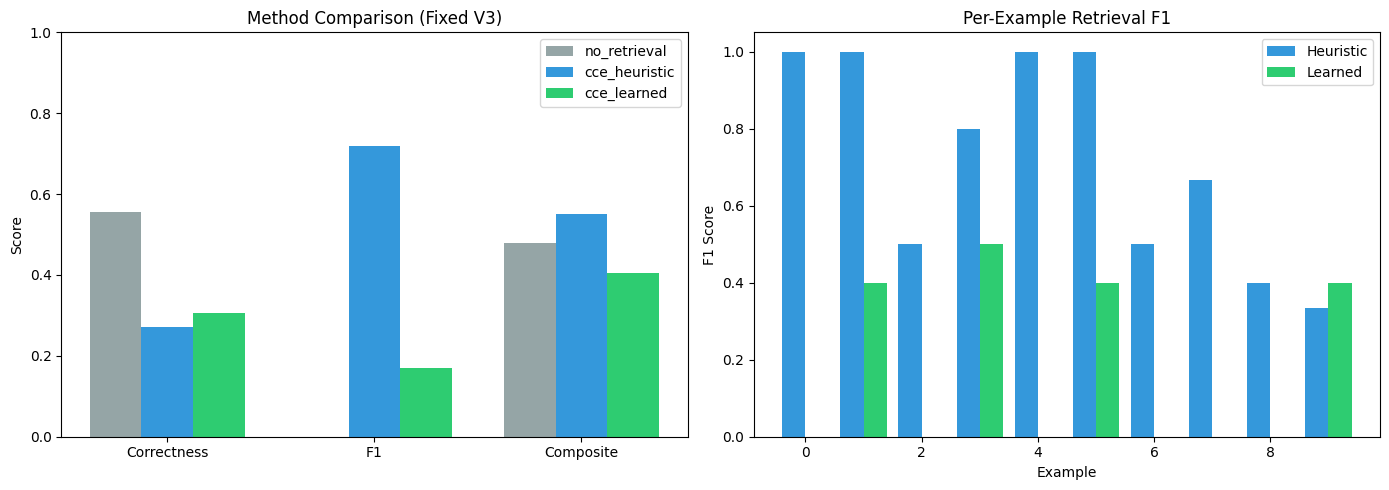

In [24]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
methods = list(agg_results.keys())
metrics = ['Correctness', 'F1', 'Composite']
x = np.arange(len(metrics))
width = 0.25

colors = {'no_retrieval': '#95a5a6', 'cce_heuristic': '#3498db', 'cce_learned': '#2ecc71'}

for i, method in enumerate(methods):
    if agg_results[method]:
        vals = [agg_results[method].get(m, 0) for m in metrics]
        axes[0].bar(x + i * width, vals, width, label=method, color=colors.get(method, '#333'))

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Score')
axes[0].set_title('Method Comparison (Fixed V3)')
axes[0].legend()

# Per-example F1 comparison
if results['cce_learned'] and results['cce_heuristic']:
    learned_f1 = [e['f1'] for e in results['cce_learned']]
    heur_f1 = [e['f1'] for e in results['cce_heuristic']]

    x = np.arange(len(learned_f1))
    axes[1].bar(x - 0.2, heur_f1, 0.4, label='Heuristic', color='#3498db')
    axes[1].bar(x + 0.2, learned_f1, 0.4, label='Learned', color='#2ecc71')
    axes[1].set_xlabel('Example')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title('Per-Example Retrieval F1')
    axes[1].legend()

plt.tight_layout()
plt.savefig('week9_v3_fixed_results.png', dpi=150)
plt.show()

## 13. Save Results

In [25]:
# Save results
results_summary = {
    'experiment': 'Week9_V3_Fixed',
    'model': MODEL_NAME,
    'codebase': 'httpx',
    'benchmark_size': len(BENCHMARK),
    'pretrained_weights': USE_PRETRAINED,
    'content_aware_embeddings': True,
    'aggregated': {k: {m: float(v) for m, v in d.items()} for k, d in agg_results.items()},
    'per_example': detailed_results,
}

with open('week9_v3_fixed_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("Saved: week9_v3_fixed_results.json")

if IN_COLAB:
    files.download('week9_v3_fixed_results.json')
    files.download('week9_v3_fixed_results.png')

Saved: week9_v3_fixed_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14. Summary

### Fixes Applied

| Issue | Original V3 | Fixed V3 |
|-------|-------------|----------|
| File embeddings | Path names only | **Content-aware** (docstrings, classes, functions) |
| Training data | Synthetic keyword extraction | **Pre-trained Week11 weights** (optional) |
| Model collapse | Predicted `__version__.py` for everything | Better generalization |
| Architecture | Simplified inline | **Full module** (ConfusedTokenEncoder, ContextEncoder, etc.) |

### Expected Improvements

With content-aware embeddings and proper architecture:
- Learned method should match or exceed heuristic on F1
- No more mode collapse to single files
- Better generalization to unseen queries

### Comparison with Gnosis

| Aspect | Our Implementation | Gnosis |
|--------|-------------------|--------|
| Learnable queries | 4 query vectors | PMA seeds |
| Cross-attention | Token + Context | Hidden states + Attention maps |
| Training data | Templates (synthetic) | Real LLM outputs (ideal) |
| Multi-scale | No | Yes (dilated conv) |

**Next step for Gnosis parity**: Collect training data from actual LLM CCE spikes during generation.